# noise test on generated data
This is a very basic calculation to show how data would look like with ideal model fit just affected by random noise. 

Conclusion: in our case the model fit is far from ideal. 

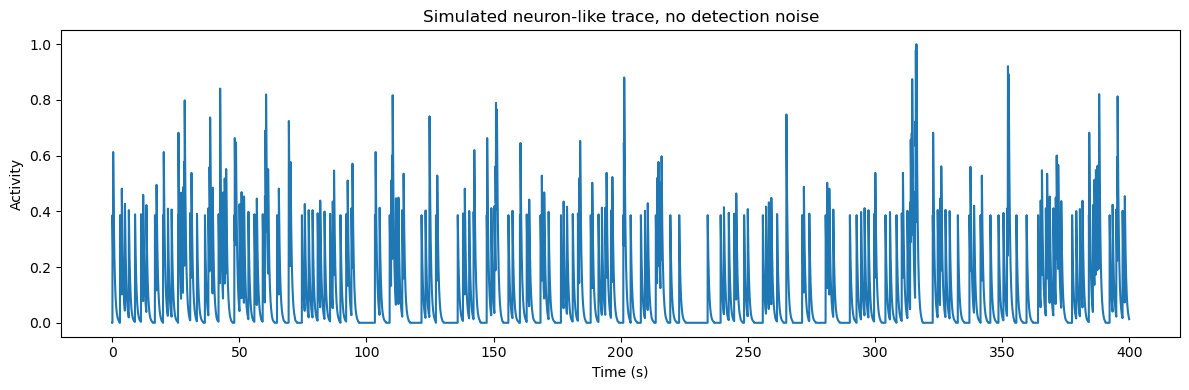

In [4]:
#ground truth
import numpy as np
import matplotlib.pyplot as plt

# random seed
rng = np.random.default_rng(0)

n_timepoints = 12_000
fps = 30
t = np.arange(n_timepoints) / fps

# sparse neural events
event_rate = 0.02
events = rng.random(n_timepoints) < event_rate

# calcium-like exponential decay kernel
tau = 0.5  # seconds
kernel_t = np.arange(0, 5 * tau, 1 / fps)
kernel = np.exp(-kernel_t / tau)

# noiseless calcium trace
trace = np.convolve(events.astype(float), kernel, mode="full")[:n_timepoints]

# normalize
base_trace = trace / trace.max()

plt.figure(figsize=(12, 4))
plt.plot(t, base_trace)
plt.xlabel("Time (s)")
plt.ylabel("Activity")
plt.title("Simulated neuron-like trace, no detection noise")
plt.tight_layout()
plt.show()

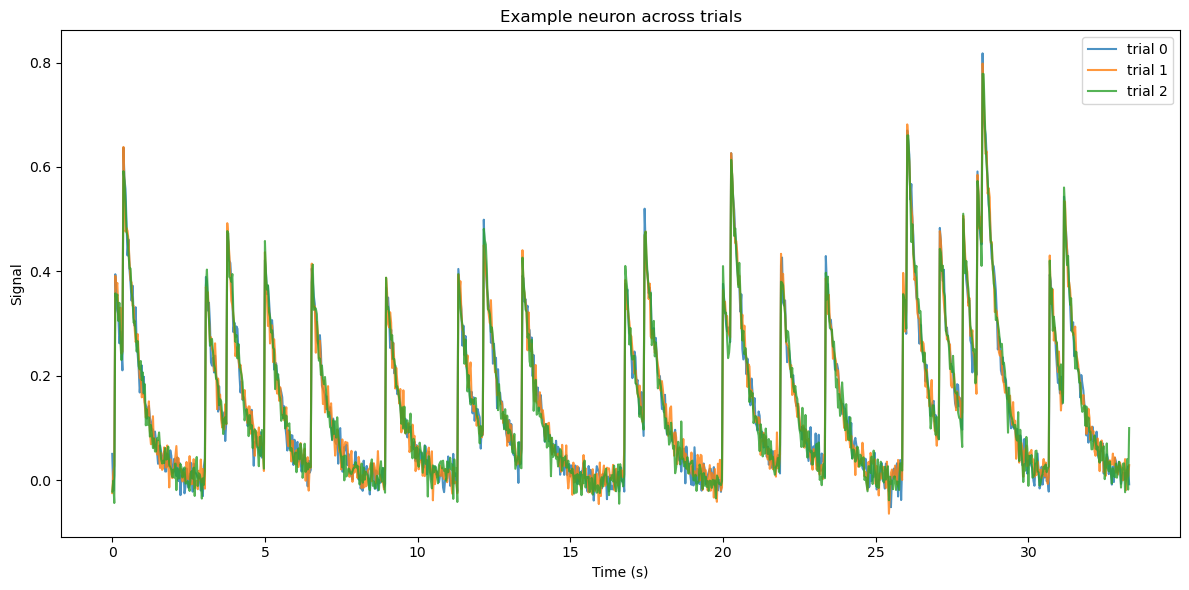

(3, 12000, 100)


In [5]:
# generating noisy data
# ---------------- parameters ----------------
n_trials = 3
n_neurons = 100

# neuron-specific noise levels
noise_levels = np.linspace(0.02, 1.0, n_neurons)
noise_levels = np.logspace(np.log10(0.02), np.log10(10), n_neurons)

# ---------------- generate dataset ----------------
# shape: (n_trials, n_timepoints, n_neurons)
data = np.empty(
    (n_trials, n_timepoints, n_neurons),
    dtype=np.float32
)

for ni in range(n_neurons):

    noise_std = noise_levels[ni]

    for tr in range(n_trials):

        noise = rng.normal(
            loc=0,
            scale=noise_std,
            size=n_timepoints
        )

        data[tr, :, ni] = base_trace + noise

# ---------------- example plot ----------------
plt.figure(figsize=(12, 6))

for tr in range(n_trials):
    plt.plot(
        t[:1000],
        data[tr, :1000, 0],
        alpha=0.8,
        label=f"trial {tr}"
    )

plt.xlabel("Time (s)")
plt.ylabel("Signal")
plt.title("Example neuron across trials")
plt.legend()

plt.tight_layout()
plt.show()

print(data.shape)

In [6]:
from analysis_utils import compute_respcorr_split_half

# compute repetability by trial
respcorr=compute_respcorr_split_half(data)

# " We define as “visually responsive neurons” all neurons with a repeatability higher than 0.2"
responsive_neurons = np.where(respcorr > 0.2 )
print(f"Number of visually responsive neurons (repeatability > 0.2): {np.count_nonzero(responsive_neurons)} out of {len(respcorr)} ({np.count_nonzero(responsive_neurons)/len(respcorr)*100:.1f}%)")

Computing split-half correlation per neuron: 100%|██████████| 100/100 [00:00<00:00, 1999.04it/s]

Number of visually responsive neurons (repeatability > 0.2): 45 out of 100 (45.0%)


Text(0.5, 0, 'Repeatability (respcorr)')

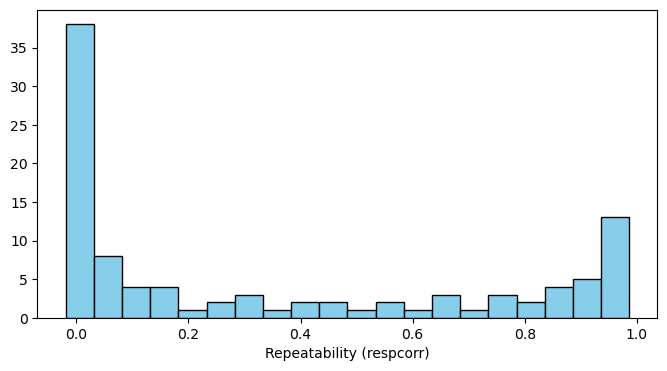

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(respcorr, bins=20, color="skyblue", edgecolor="black")
plt.xlabel("Repeatability (respcorr)")

Text(0, 0.5, 'Noise level (std)')

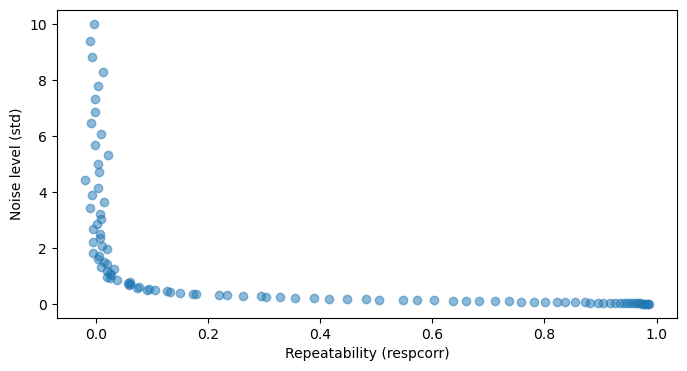

In [8]:
plt.figure(figsize=(8, 4))
plt.scatter(respcorr, noise_levels, alpha=0.5)
plt.xlabel("Repeatability (respcorr)")
plt.ylabel("Noise level (std)")


In [9]:
train_split=0.85
train_split_index=int(n_timepoints*train_split)
trace_train=data[:, :train_split_index, :]
trace_test=data[:, train_split_index:, :]
train_base_trace=base_trace[:train_split_index]
test_base_trace=base_trace[train_split_index:]

In [10]:
# generate r_train as the correlation of base_trace with the mean response across trials in the training set for each neuron
r_train = np.empty((n_neurons,))
for ni in range(n_neurons):
    mean_response_train = trace_train[:, :, ni].mean(axis=0)
    r_train[ni] = np.corrcoef(train_base_trace, mean_response_train)[0, 1]    

# generate r_test as the correlation of base_trace with the mean response across trials in the test set for each neuron
r_test = np.empty((n_neurons,))
for ni in range(n_neurons):
    mean_response_test = trace_test[:, :, ni].mean(axis=0)
    r_test[ni] = np.corrcoef(test_base_trace, mean_response_test)[0, 1]

(0.0, 1.0)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


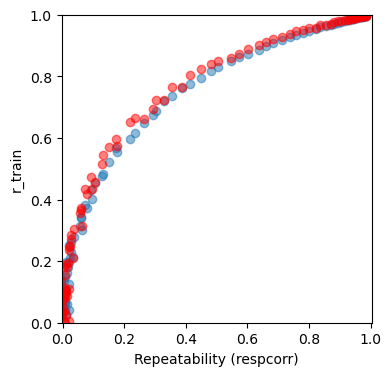

In [11]:
plt.figure(figsize=(4, 4))
plt.scatter(respcorr, r_train, alpha=0.5)
plt.scatter(respcorr, r_test, alpha=0.5, color="red")
plt.xlabel("Repeatability (respcorr)")
plt.ylabel("r_train")

#set axis equal
plt.axis("equal")
plt.ylim(0, 1)
plt.xlim(0, 1)


(0.0, 1.0)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


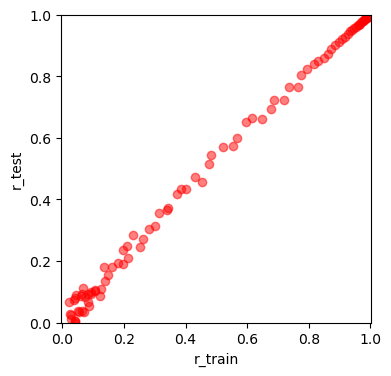

In [12]:
plt.figure(figsize=(4, 4))
plt.scatter(r_train, r_test, alpha=0.5, color="red")
plt.xlabel("r_train")
plt.ylabel("r_test")

#set axis equal
plt.axis("equal")
plt.ylim(0, 1)
plt.xlim(0, 1)

In [13]:
print(f"Done. n_neurons: {n_neurons}, n_trials: {n_trials}, n_timepoints: {n_timepoints}")

Done. n_neurons: 100, n_trials: 3, n_timepoints: 12000
